In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Garantir reprodutibilidade nos experimentos
torch.manual_seed(123)

print(f"PyTorch Version: {torch.__version__}")
print("Ambiente configurado com sucesso!")

PyTorch Version: 2.13.0+cu130
Ambiente configurado com sucesso!


In [4]:
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Cálculo das pontuações de atenção: Q * K^T
        attn_scores = queries @ keys.transpose(-2, -1)
        
        # Softmax sem escala
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # Vetores de contexto
        context_vec = attn_weights @ values
        return context_vec, attn_weights

# Teste unitário simples
inputs = torch.rand(2, 4, 8) # batch_size=2, num_tokens=4, d_in=8
sa = SelfAttention(d_in=8, d_out=16)
context_vec, weights = sa(inputs)
print("Self-Attention - Formato de saída:", context_vec.shape)

Self-Attention - Formato de saída: torch.Size([2, 4, 16])


In [5]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)

        # Máscara causal triangular superior (buffer permanente)
        self.register_buffer(
            "mask", 
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Scaled Dot-Product
        d_k = keys.shape[-1]
        attn_scores = (queries @ keys.transpose(-2, -1)) / (d_k ** 0.5)

        # Aplicação da máscara Causal
        mask_bool = self.mask[:num_tokens, :num_tokens].bool()
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec, attn_weights

ca = CausalAttention(d_in=8, d_out=16, context_length=4, dropout=0.0)
context_vec, weights = ca(inputs)
print("Causal Attention - Formato de saída:", context_vec.shape)

Causal Attention - Formato de saída: torch.Size([2, 4, 16])


In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out deve ser divisível por num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # Projeção e reordenação das dimensões para as heads: (b, num_heads, num_tokens, head_dim)
        keys    = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = (queries @ keys.transpose(-2, -1)) / (self.head_dim ** 0.5)

        mask_bool = self.mask[:num_tokens, :num_tokens].bool()
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Agregação e recombinação das cabeças
        context_vec = (attn_weights @ values).transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        return self.out_proj(context_vec), attn_weights

mha = MultiHeadAttention(d_in=8, d_out=16, context_length=4, dropout=0.0, num_heads=2)
context_vec, mha_weights = mha(inputs)
print("Multi-Head Attention - Formato de saída:", context_vec.shape)

Multi-Head Attention - Formato de saída: torch.Size([2, 4, 16])


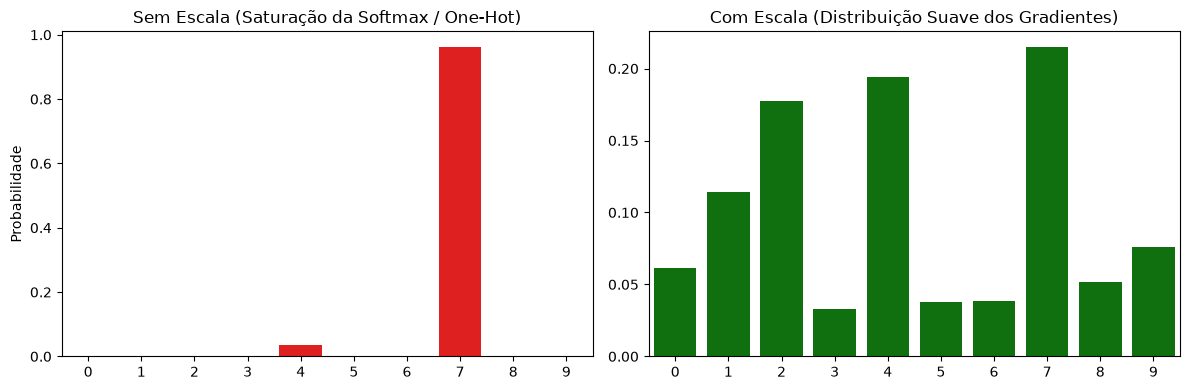

In [7]:
def experimento_escala():
    d_k = 1024
    q = torch.randn(1, d_k)
    k = torch.randn(10, d_k)

    scores_sem_escala = q @ k.T
    scores_com_escala = (q @ k.T) / (d_k ** 0.5)

    weights_sem_escala = torch.softmax(scores_sem_escala, dim=-1)
    weights_com_escala = torch.softmax(scores_com_escala, dim=-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.barplot(x=list(range(10)), y=weights_sem_escala.squeeze().numpy(), ax=axes[0], color='red')
    axes[0].set_title("Sem Escala (Saturação da Softmax / One-Hot)")
    axes[0].set_ylabel("Probabilidade")

    sns.barplot(x=list(range(10)), y=weights_com_escala.squeeze().numpy(), ax=axes[1], color='green')
    axes[1].set_title("Com Escala (Distribuição Suave dos Gradientes)")
    
    plt.tight_layout()
    plt.show()

experimento_escala()